# Interactive region pairing and refinement tool

This notebook explains how to run and use the **spAlignDE Interactive Region
Pairing Tool**. The Streamlit interface displays two spatial datasets side by
side, lets users select or merge segmented regions, records region
correspondences, and exports the curated mappings as CSV.

Use this tool when automatic region pairing needs visual review, when one
biological structure is split across several clusters or labels, or when a
correspondence must be refined before alignment. The interface supports:

- point/cluster CSV data, including clustered cells or capture spots;
- two-dimensional NPY label images, including clustered image features;
- the built-in Allen CCF atlas.

The Streamlit server is launched from a terminal. The executable cells in this
notebook check the installation, describe the input and output contracts, and
optionally validate an exported pairing table without starting a blocking
server inside Jupyter.

## 1. Install the interface

Clone or download spAlignDE, then create an environment inside the UI folder.
The interface must be started from this folder because the Allen annotation,
region metadata, Plotly component, and upload manifest are resolved relative
to it.

```bash
cd /path/to/spAlignDE/pipeline/FF/UI/spalign-ui
python -m venv .venv
source .venv/bin/activate
python -m pip install -r requirements.txt
```

On Windows, replace the activation command with:

```bat
.venv\Scripts\activate
```

Do not copy local `.venv` folders or `.DS_Store` files when distributing the
tool.

In [1]:
from pathlib import Path
import os

import pandas as pd
from IPython.display import Image, display

SPALIGNDE_ROOT = Path(
    os.environ.get("SPALIGNDE_ROOT", "/path/to/spAlignDE")
).expanduser()
UI_DIR = SPALIGNDE_ROOT / "pipeline" / "FF" / "UI" / "spalign-ui"

required_paths = [
    "app_experimental.py",
    "requirements.txt",
    "annotation_10.nrrd",
    "voxel_count_and_differences.csv",
    "plotly_mode_component/index.html",
    "plotly_mode_component/static/js/main.v7.js",
    "uploaded_datasets",
]
missing = [name for name in required_paths if not (UI_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        "Set SPALIGNDE_ROOT to the cloned spAlignDE repository. Missing: "
        + ", ".join(missing)
    )

print("UI installation check passed.")
print(f"Required application files found: {len(required_paths)}")

UI installation check passed.
Required application files found: 7


## 2. Prepare an input dataset

Open **Upload custom dataset** and choose one of the following formats. The
uploaded dataset is retained in the interface's `uploaded_datasets/` folder
and registered in `manifest.json`.

| Format | Required content | Interface behavior |
|---|---|---|
| Point/cluster CSV | One row per cell or spot; two numeric coordinate columns; one numeric cluster/label column | Select the x, y, and label columns after upload. Column names may differ from `x`, `y`, and `cluster`. |
| 2D label-image NPY | A two-dimensional numeric array in which each segmented region has one label | Finite labels are selectable regions; `NaN` and `-1` are background. |
| Allen CCF atlas | No upload | Choose **Allen CCF Atlas** as a panel dataset and select the desired z slice and flips. |

For a point/cluster CSV, the minimal standardized layout is:

```text
x,y,cluster
103.2,51.8,0
104.1,50.9,0
212.7,84.3,1
```

Coordinates and labels must be convertible to numeric values. Remove missing
coordinates before upload. Cluster labels should be integer-like values.

In [2]:
input_contract = pd.DataFrame(
    [
        {
            "input": "Point/cluster CSV",
            "shape": "rows = cells or spots",
            "required": "numeric x, numeric y, numeric label",
            "background": "not applicable",
        },
        {
            "input": "2D label-image NPY",
            "shape": "height × width",
            "required": "one numeric label per region",
            "background": "NaN or -1",
        },
        {
            "input": "Allen CCF atlas",
            "shape": "built-in 3D annotation",
            "required": "z slice; optional flips",
            "background": "handled by the app",
        },
    ]
)
display(input_contract)

,input,shape,required,background
0,Point/cluster CSV,rows = cells or spots,"numeric x, numeric y, numeric label",not applicable
1,2D label-image NPY,height × width,one numeric label per region,NaN or -1
2,Allen CCF atlas,built-in 3D annotation,z slice; optional flips,handled by the app


## 3. Start the application

Run the presentation-ready entry point from a terminal:

```bash
cd /path/to/spAlignDE/pipeline/FF/UI/spalign-ui
source .venv/bin/activate
streamlit run app_experimental.py
```

Streamlit normally opens the interface in a browser. If it does not, open the
local URL printed in the terminal, usually `http://localhost:8501`. Keep the
terminal process running while using the interface. Stop it with `Ctrl+C`.

`app.py` is an earlier prototype; use `app_experimental.py` for the workflow
documented below.

## 4. Select the two datasets

1. Expand **Upload custom dataset** to add a point/cluster CSV or 2D NPY label
   image.
2. In the two **Dataset settings** panels, choose the datasets to compare.
3. Use either panel for the query or reference; left/right placement does not
   change the meaning of the saved correspondence.
4. When using Allen CCF, confirm the z slice and horizontal/vertical flips
   before curating regions.

The only built-in dataset is **Allen CCF Atlas**. Uploaded datasets appear in
the same left and right dataset menus.

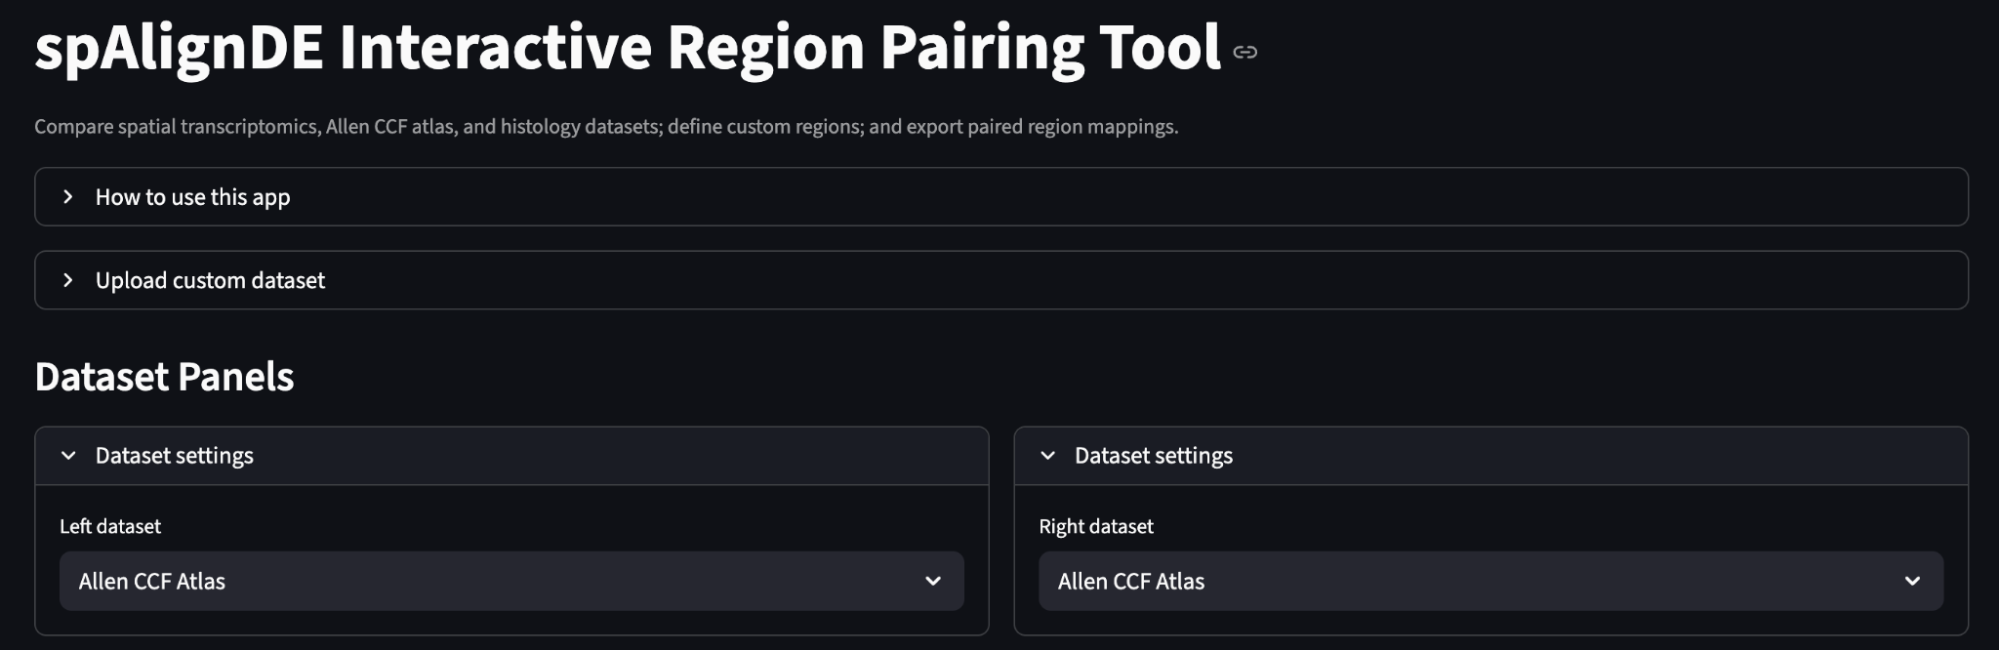

In [3]:
display(
    Image(
        filename=str(
            SPALIGNDE_ROOT
            / "pipeline" / "FF" / "docs" / "assets"
            / "interactive_region_pairing" / "01_dataset_selection.png"
        ),
        alt="Dataset upload and panel selection",
    )
)

## 5. Navigate and select regions

Use the Plotly toolbar above each image:

- **Zoom** or the mouse wheel enlarges a structure.
- **Pan** moves around the tissue without modifying the selection.
- **Select** activates region selection; click or drag across one or more
  colored structures.
- **Home/Reset** restores the complete view.

The **Selected Regions** table lists the selected IDs and available metadata.
Check this table before grouping regions, especially for thin adjacent
structures such as hippocampal layers. Use **Clear selected regions** to start
the selection again.

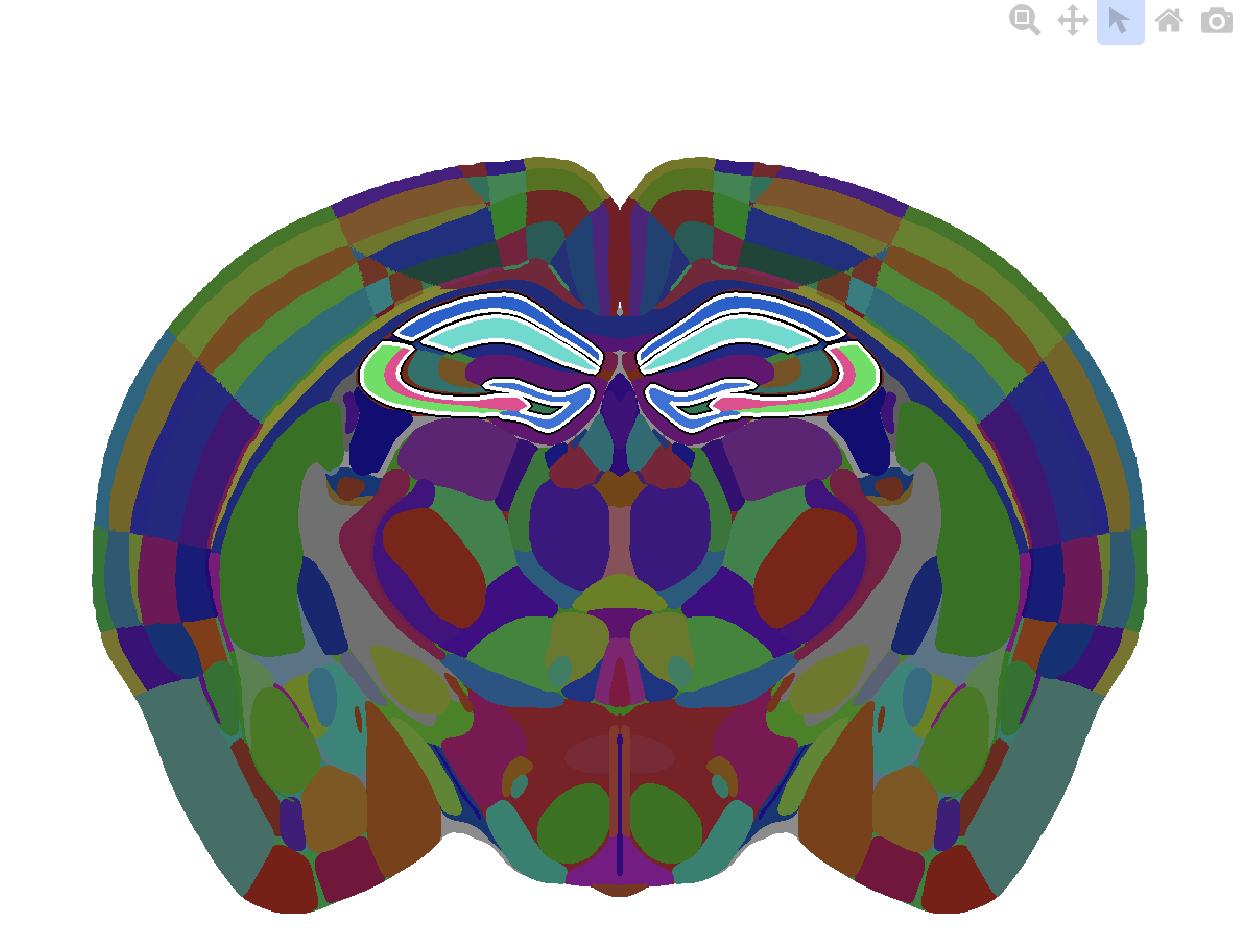

In [4]:
display(
    Image(
        filename=str(
            SPALIGNDE_ROOT
            / "pipeline" / "FF" / "docs" / "assets"
            / "interactive_region_pairing" / "02_region_selection.png"
        ),
        alt="Region selection in the Plotly viewer",
    )
)

## 6. Group regions for pairing or refinement

Automatic clustering or segmentation can split one biological structure into
multiple pieces. Select all pieces that should be treated as one unit, enter a
descriptive **Custom region name**, and click **Create custom region**.

Choose the reuse rule deliberately:

- **Flexible reuse mode** allows one source region to participate in several
  custom regions. Use it while exploring alternative correspondences.
- **Exclusive assignment mode** permits each source region in only one custom
  region. Use it for a final non-overlapping annotation.

A custom region stores the included source IDs rather than modifying the input
CSV or NPY file. This makes manual refinement reversible and auditable.

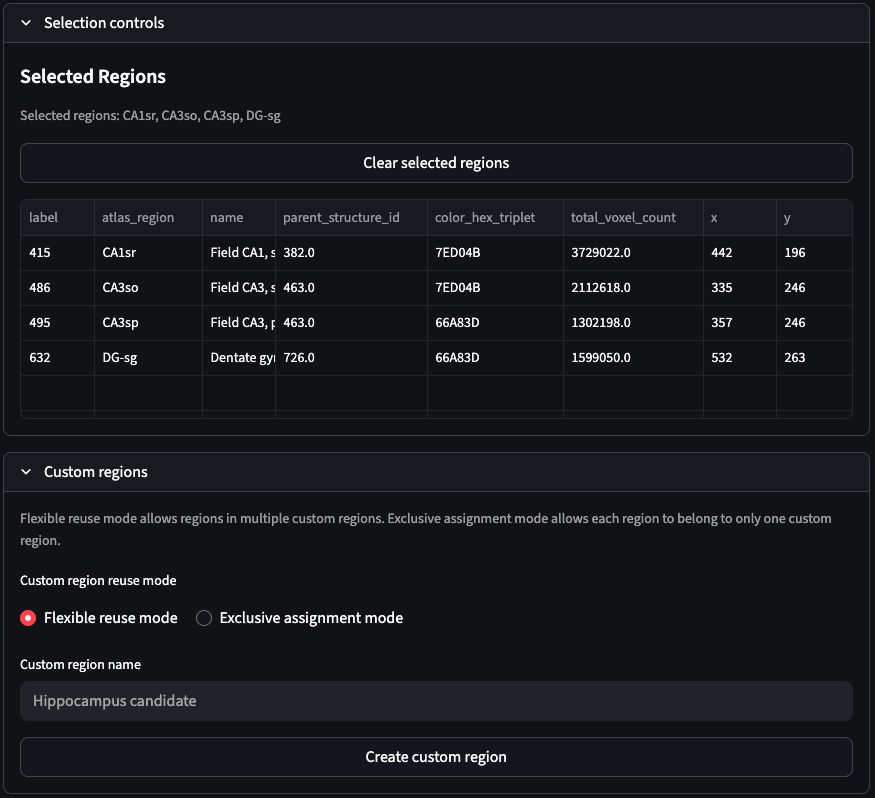

In [5]:
display(
    Image(
        filename=str(
            SPALIGNDE_ROOT
            / "pipeline" / "FF" / "docs" / "assets"
            / "interactive_region_pairing" / "03_create_custom_region.png"
        ),
        alt="Creating a custom region from selected structures",
    )
)

## 7. Inspect the refined region

The selected custom region is highlighted in the viewer. Confirm that the
grouped pieces form the intended anatomical structure and do not include a
large neighboring region. If the grouping is incorrect, delete or rename it
from **Custom Regions**, revise the selection, and create it again.

For atlas refinement, inspect both shape and thickness rather than relying
only on region area. For point data, also check whether the selected clusters
form a spatially continuous structure.

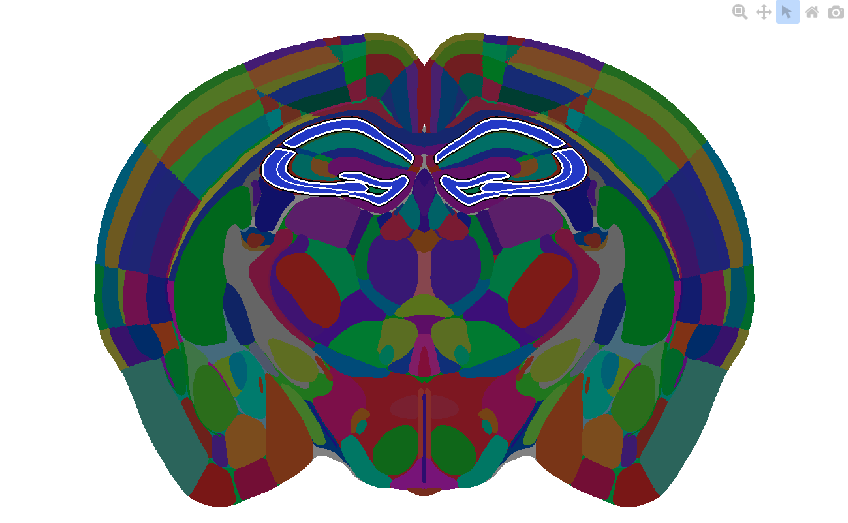

In [6]:
display(
    Image(
        filename=str(
            SPALIGNDE_ROOT
            / "pipeline" / "FF" / "docs" / "assets"
            / "interactive_region_pairing" / "04_custom_region_preview.png"
        ),
        alt="Preview of a grouped custom anatomical region",
    )
)

## 8. Compare the two panels and save a pair

Navigation is independent in the left and right viewers, so zoom each panel to
the relevant structure. Select either raw regions or custom regions on both
sides, then click **Save grouped pair**.

One saved group may contain multiple selected regions on either side. The
export therefore contains one row for every left-right combination, while the
shared `group_id` preserves the many-to-many correspondence. Do not interpret
each CSV row as an independent biological assertion without considering its
group.

For manual refinement of an automatic match, use the candidate list as a
reference, inspect the corresponding structures in both panels, regroup only
the structures that need correction, and save the visually supported pair.
The current interface does not automatically import an existing candidate-pair
table.

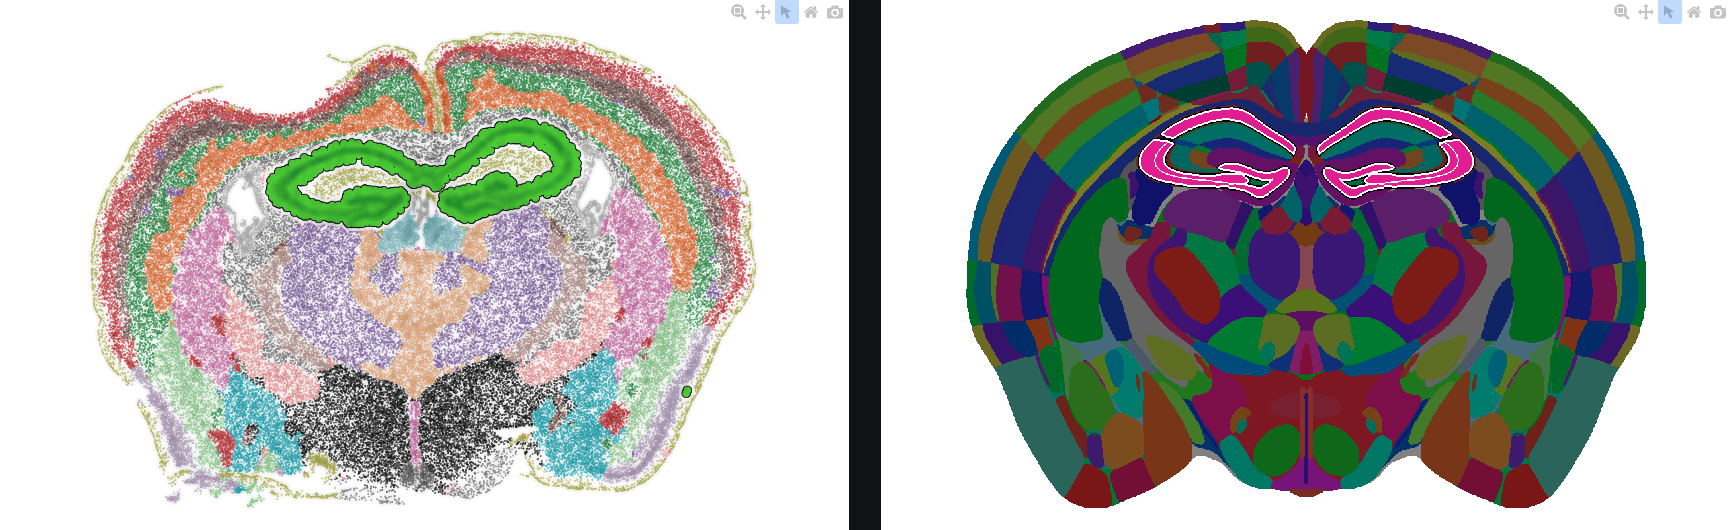

In [7]:
display(
    Image(
        filename=str(
            SPALIGNDE_ROOT
            / "pipeline" / "FF" / "docs" / "assets"
            / "interactive_region_pairing" / "05_side_by_side_comparison.png"
        ),
        alt="Side-by-side comparison of ST and atlas regions",
    )
)

## 9. Export the curated mapping

Review **Saved Pairs** and click **Export CSV**. The browser downloads
`spalign_de_experimental_pairs.csv`; the application does not write this file
to disk automatically. The separate **Custom Regions** export downloads
`spalign_de_custom_regions.csv` and records how grouped structures were
constructed.

Keep both files when custom regions were used. Together they record the final
pairing and the source IDs included in each manually defined structure.

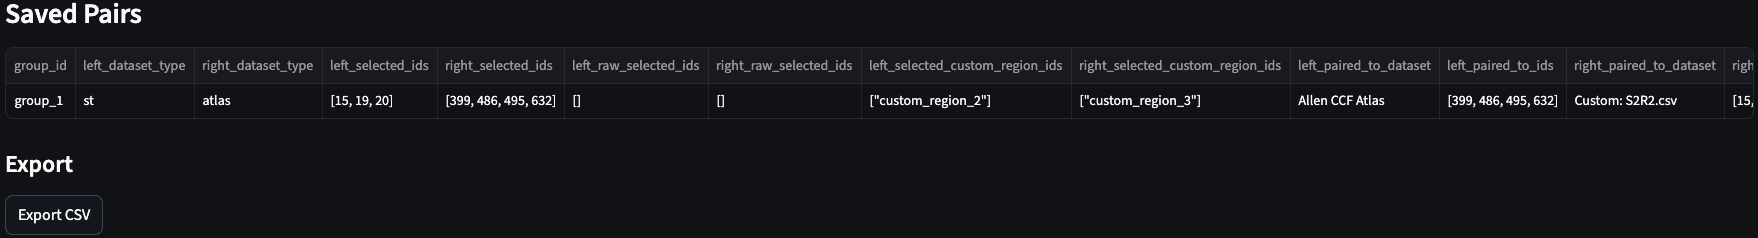

In [8]:
display(
    Image(
        filename=str(
            SPALIGNDE_ROOT
            / "pipeline" / "FF" / "docs" / "assets"
            / "interactive_region_pairing" / "06_export_pairs.png"
        ),
        alt="Saved pairs table and CSV export",
    )
)

## 10. Understand the pairing export

The pairing CSV contains detailed provenance for both panels. The most useful
fields are summarized below. Additional columns preserve selected coordinates,
region sizes, atlas metadata, rotations, flips, upload filenames, and custom
region definitions.

In [9]:
export_fields = pd.DataFrame(
    [
        ("group_id", "Groups all rows belonging to one many-to-many correspondence."),
        ("left_selected_ids / right_selected_ids", "Complete source-ID sets selected in each panel."),
        ("left_selection_type / right_selection_type", "Whether the row represents a raw or custom region."),
        ("left_selected_id / right_selected_id", "The individual raw or custom ID represented by the row."),
        ("left_selected_name / right_selected_name", "Display names used during review."),
        ("*_included_region_ids", "Original IDs merged into a custom region, encoded as a JSON list."),
        ("*_dataset_kind", "Dataset type: st, histology, or atlas."),
        ("*_rotation_angle", "Panel rotation used during visual review."),
        ("atlas_z_slice / atlas_flip_*", "Allen CCF slice and orientation used for the saved pair."),
    ],
    columns=["field", "meaning"],
)
display(export_fields)

,field,meaning
0,group_id,Groups all rows belonging to one many-to-many ...
1,left_selected_ids / right_selected_ids,Complete source-ID sets selected in each panel.
2,left_selection_type / right_selection_type,Whether the row represents a raw or custom reg...
3,left_selected_id / right_selected_id,The individual raw or custom ID represented by...
4,left_selected_name / right_selected_name,Display names used during review.
5,*_included_region_ids,"Original IDs merged into a custom region, enco..."
6,*_dataset_kind,"Dataset type: st, histology, or atlas."
7,*_rotation_angle,Panel rotation used during visual review.
8,atlas_z_slice / atlas_flip_*,Allen CCF slice and orientation used for the s...


Optionally set `SPALIGNDE_PAIRING_CSV` to a downloaded pairing file before
running the next cell. It checks the core grouping and provenance columns and
reports the number of saved correspondence groups.

In [10]:
pairing_csv = os.environ.get("SPALIGNDE_PAIRING_CSV")

if pairing_csv:
    pairs = pd.read_csv(Path(pairing_csv).expanduser())
    required_export_columns = {
        "group_id",
        "left_selected_ids",
        "right_selected_ids",
        "left_selection_type",
        "right_selection_type",
        "left_selected_id",
        "right_selected_id",
    }
    missing_columns = sorted(required_export_columns.difference(pairs.columns))
    if missing_columns:
        raise ValueError("Pairing CSV is missing: " + ", ".join(missing_columns))
    print(f"Validated {len(pairs):,} rows in {pairs['group_id'].nunique():,} pairing groups.")
    display(pairs.head())
else:
    print("Set SPALIGNDE_PAIRING_CSV to validate a downloaded pairing export.")

Set SPALIGNDE_PAIRING_CSV to validate a downloaded pairing export.


## 11. Recommended refinement checklist

Before using a curated mapping in alignment:

1. Confirm the query and reference datasets, Allen slice, flips, and rotations.
2. Check thin structures at high zoom and compare shape, thickness, area, and
   spatial neighborhood.
3. Use descriptive custom-region names and retain the original included IDs.
4. Prefer exclusive assignment for the final mapping unless biological overlap
   is intentional.
5. Review every `group_id`, not only individual rows in the exported table.
6. Save the pairing CSV and custom-region CSV with the alignment configuration
   and output coordinates.

### Troubleshooting

- **The app cannot find Allen data:** start Streamlit from
  `pipeline/FF/UI/spalign-ui`, not another working directory.
- **A CSV upload has no usable columns:** ensure x, y, and label fields are
  numeric and coordinates are finite.
- **An NPY upload fails:** confirm that the array is two-dimensional and uses
  numeric region labels.
- **Clicks select the wrong structure:** activate Select mode, zoom in, and
  verify the Selected Regions table; use Pan mode only for navigation.
- **An exported group creates several rows:** this is expected for many-to-many
  selections; reconstruct the correspondence using `group_id`.
- **No downloaded file appears in the project folder:** exports are browser
  downloads, so check the browser's download location.